In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    mean_squared_error,
    accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix,
    classification_report
)

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [6]:
import urllib.request
import zipfile
import os

url = "https://archive.ics.uci.edu/static/public/320/student+performance.zip"

urllib.request.urlretrieve(url, "student_performance.zip")

with zipfile.ZipFile("student_performance.zip", "r") as zip_ref:
    zip_ref.extractall("student_data")

print("Dataset downloaded successfully!")
print(os.listdir("student_data"))

Dataset downloaded successfully!
['student-mat.csv', 'student.txt', '.student.zip_old', 'student.zip', 'student-por.csv', 'student-merge.R']


In [4]:
import os

print(os.listdir("student_data"))

['.student.zip_old', 'student.zip']


In [8]:
import zipfile
import os

with zipfile.ZipFile("student_data/student.zip", "r") as zip_ref:
    zip_ref.extractall("student_data")

print(os.listdir("student_data"))

['student-mat.csv', 'student.txt', '.student.zip_old', 'student.zip', 'student-por.csv', 'student-merge.R']


In [9]:
df = pd.read_csv(
    "student_data/student-mat.csv",
    sep=";"
)

print("Dataset Loaded Successfully!")

print("\nDataset Shape:")
print(df.shape)

print("\nFirst 5 Rows:")
display(df.head())

Dataset Loaded Successfully!

Dataset Shape:
(395, 33)

First 5 Rows:


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [10]:
print("Missing Values:")
print(df.isnull().sum())

print("\nTotal Missing Values:")
print(df.isnull().sum().sum())

Missing Values:
school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64

Total Missing Values:
0


In [11]:
# Select required features
X = df[["studytime", "absences", "G1", "G2"]].copy()

# Target: Final Grade
y_reg = df["G3"]

# Create Pass/Fail target
y_class = (df["G3"] >= 10).astype(int)

print("Features:")
display(X.head())

print("\nPass/Fail Distribution:")
print(y_class.value_counts())

Features:


,studytime,absences,G1,G2
0,2,6,5,6
1,2,4,5,5
2,2,10,7,8
3,3,2,15,14
4,2,4,6,10



Pass/Fail Distribution:
G3
1    265
0    130
Name: count, dtype: int64


In [12]:
X_train, X_test, y_reg_train, y_reg_test = train_test_split(
    X, y_reg,
    test_size=0.2,
    random_state=42
)

_, _, y_class_train, y_class_test = train_test_split(
    X, y_class,
    test_size=0.2,
    random_state=42
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training data shape:", X_train_scaled.shape)
print("Testing data shape:", X_test_scaled.shape)
print("Scaling completed successfully!")

Training data shape: (316, 4)
Testing data shape: (79, 4)
Scaling completed successfully!


In [13]:
linear_model = LinearRegression()

linear_model.fit(X_train_scaled, y_reg_train)

y_reg_pred = linear_model.predict(X_test_scaled)

mse = mean_squared_error(y_reg_test, y_reg_pred)
rmse = np.sqrt(mse)

print("Linear Regression Results")
print("MSE:", mse)
print("RMSE:", rmse)

Linear Regression Results
MSE: 4.178975406386837
RMSE: 2.044254242110515


In [14]:
logistic_model = LogisticRegression()

logistic_model.fit(X_train_scaled, y_class_train)

y_class_pred = logistic_model.predict(X_test_scaled)

accuracy = accuracy_score(y_class_test, y_class_pred)
precision = precision_score(y_class_test, y_class_pred)
recall = recall_score(y_class_test, y_class_pred)

print("Logistic Regression Results")
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)

Logistic Regression Results
Accuracy: 0.8987341772151899
Precision: 0.9583333333333334
Recall: 0.8846153846153846


Confusion Matrix:
[[25  2]
 [ 6 46]]


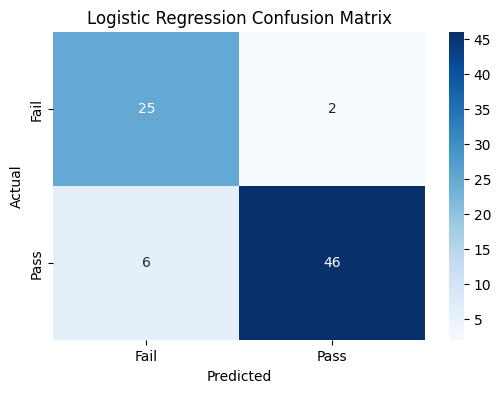

In [15]:
cm = confusion_matrix(y_class_test, y_class_pred)

print("Confusion Matrix:")
print(cm)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Fail", "Pass"],
    yticklabels=["Fail", "Pass"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")
plt.show()

In [16]:
print("Classification Report:")
print(classification_report(
    y_class_test,
    y_class_pred,
    target_names=["Fail", "Pass"]
))

Classification Report:
              precision    recall  f1-score   support

        Fail       0.81      0.93      0.86        27
        Pass       0.96      0.88      0.92        52

    accuracy                           0.90        79
   macro avg       0.88      0.91      0.89        79
weighted avg       0.91      0.90      0.90        79



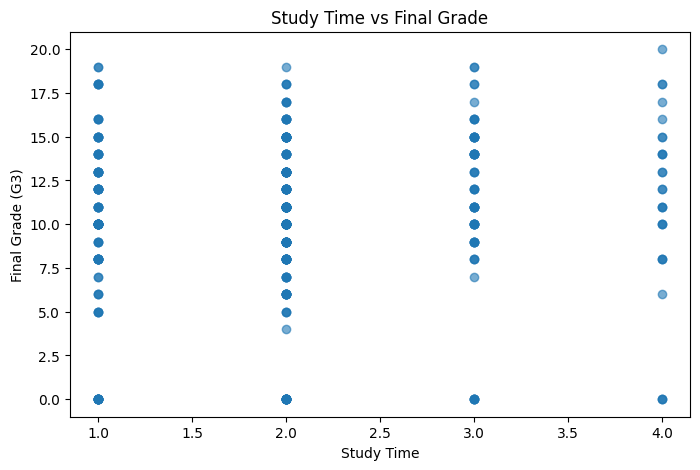

In [17]:
plt.figure(figsize=(8, 5))

plt.scatter(df["studytime"], df["G3"], alpha=0.6)

plt.xlabel("Study Time")
plt.ylabel("Final Grade (G3)")
plt.title("Study Time vs Final Grade")

plt.show()

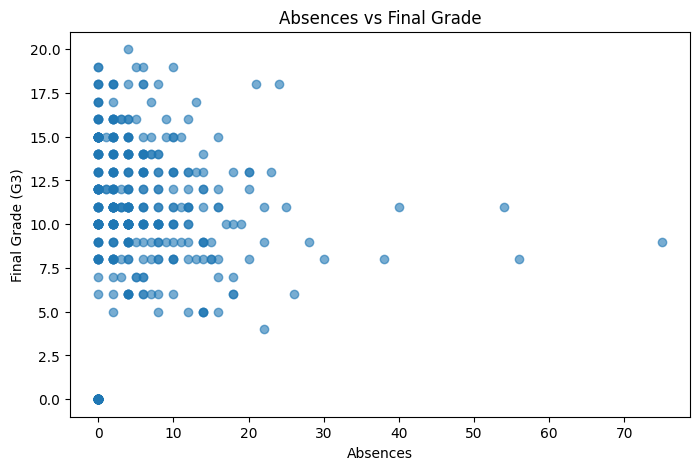

In [18]:
plt.figure(figsize=(8, 5))

plt.scatter(df["absences"], df["G3"], alpha=0.6)

plt.xlabel("Absences")
plt.ylabel("Final Grade (G3)")
plt.title("Absences vs Final Grade")

plt.show()

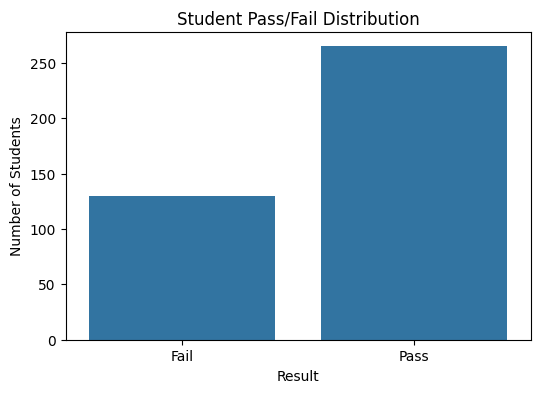

In [19]:
plt.figure(figsize=(6, 4))

sns.countplot(x=y_class)

plt.xlabel("Result")
plt.ylabel("Number of Students")
plt.title("Student Pass/Fail Distribution")
plt.xticks([0, 1], ["Fail", "Pass"])

plt.show()